In [1]:
# For data menupulation and analysis
import numpy as np
import pandas as pd

# for data prepocessing and pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Dealing with missing data
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# all the models.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv("/Users/harrish/Documents/Titanic_ML_Project/notebook/data/Titanic Dataset.csv")

In [3]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [195]:
df.drop(['name', 'ticket','cabin','boat','body','home.dest'], axis=1, inplace=True)

In [196]:
df.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.00,0,0,211.3375,S
1,1,1,male,0.92,1,2,151.5500,S
2,1,0,female,2.00,1,2,151.5500,S
3,1,0,male,30.00,1,2,151.5500,S
4,1,0,female,25.00,1,2,151.5500,S


In [197]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [198]:
X

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,29.00,0,0,211.3375,S
1,1,male,0.92,1,2,151.5500,S
2,1,female,2.00,1,2,151.5500,S
3,1,male,30.00,1,2,151.5500,S
4,1,female,25.00,1,2,151.5500,S
...,...,...,...,...,...,...,...
1304,3,female,14.50,1,0,14.4542,C
1305,3,female,NaN,1,0,14.4542,C
1306,3,male,26.50,0,0,7.2250,C
1307,3,male,27.00,0,0,7.2250,C


In [199]:
# creating column transformers and preprocessing pipeline

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()


/var/folders/0k/47mbjlc122lgv2xq32gh02sh0000gn/T/ipykernel_31669/2907771566.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [200]:
print(numeric_features)
print(categorical_features)


['pclass', 'age', 'sibsp', 'parch', 'fare']
['sex', 'embarked']


In [201]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

oh_endcoding = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("OneHotEncoder", OneHotEncoder())
])

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_endcoding, categorical_features),
        ("StandardScaler", numeric_transformer, numeric_features),
    ]
)

In [202]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [203]:
X = preprocessor.fit_transform(X)

X

array([[ 1.        ,  0.        ,  0.        , ..., -0.47908676,
        -0.4449995 ,  3.44258413],
       [ 0.        ,  1.        ,  0.        , ...,  0.48128777,
         1.86652569,  2.2866387 ],
       [ 1.        ,  0.        ,  0.        , ...,  0.48128777,
         1.86652569,  2.2866387 ],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -0.47908676,
        -0.4449995 , -0.50377442],
       [ 0.        ,  1.        ,  1.        , ..., -0.47908676,
        -0.4449995 , -0.50377442],
       [ 0.        ,  1.        ,  0.        , ..., -0.47908676,
        -0.4449995 , -0.49120717]], shape=(1309, 10))

In [204]:
X.shape

(1309, 10)

In [210]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [213]:
# Model Evaluation for classification problem.

def evaluate_model(true, prediction):
    accuracy = accuracy_score(true, prediction)
    precision = precision_score(true, prediction)
    recall = recall_score(true, prediction)
    f1 = f1_score(true, prediction)
    return accuracy, precision, recall, f1

In [252]:
# All models for the classification problems.
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier()
}

model_list = []
accuracy_list = []


for name, model in models.items():
    model = model
    model.fit(X_train, y_train) # Model training

    # Make a predictino
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test) 

    # Evaluate the model
    # For training data
    accuracy_train, precision_train, recall_train, f1_train = evaluate_model(y_train, y_train_pred)
    # for test data
    accuracy_test, precision_test, recall_test, f1_test = evaluate_model(y_test, y_test_pred)

    print(f"model name ------>{i}")
    # Storing the models in list
    model_list.append(name)


    print('Model performance for Training set')
    print("- Accuracy_train : {:.4f}".format(accuracy_train))
    print("- Precision : {:.4f}".format(precision_train))
    print("- recall : {:.4f}".format(recall_train))
    print("- F1 Score : {:.4f}".format(f1_train))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Accuracy_Test : {:.4f}".format(accuracy_test))
    print("- Precision : {:.4f}".format(precision_test))
    print("- recall : {:.4f}".format(recall_test))
    print("- F1 Score : {:.4f}".format(f1_test))

    accuracy_list.append(accuracy_test)

    print("="*35)
    print("\n")   


model name ------>Gradient Boosting Classifier
Model performance for Training set
- Accuracy_train : 0.7985
- Precision : 0.7382
- recall : 0.6937
- F1 Score : 0.7152
----------------------------------
Model performance for Test set
- Accuracy_Test : 0.7748
- Precision : 0.8172
- recall : 0.6441
- F1 Score : 0.7204


model name ------>Gradient Boosting Classifier
Model performance for Training set
- Accuracy_train : 0.8520
- Precision : 0.8328
- recall : 0.7435
- F1 Score : 0.7856
----------------------------------
Model performance for Test set
- Accuracy_Test : 0.7595
- Precision : 0.7957
- recall : 0.6271
- F1 Score : 0.7014


model name ------>Gradient Boosting Classifier
Model performance for Training set
- Accuracy_train : 0.9704
- Precision : 0.9835
- recall : 0.9346
- F1 Score : 0.9584
----------------------------------
Model performance for Test set
- Accuracy_Test : 0.7481
- Precision : 0.7766
- recall : 0.6186
- F1 Score : 0.6887


model name ------>Gradient Boosting Classif

In [253]:
print(model_list)

['Logistic Regression', 'K-Neighbors Classifier', 'Decision Tree Classifier', 'Random Forest Classifier', 'Support Vector Classifier', 'AdaBoost Classifier', 'Gradient Boosting Classifier']


In [254]:
print(accuracy_list)

[0.7748091603053435, 0.7595419847328244, 0.7480916030534351, 0.7824427480916031, 0.7748091603053435, 0.7633587786259542, 0.7786259541984732]


### Result 

In [255]:
pd.DataFrame({"Model": model_list, "Accuracy": accuracy_list}).sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
3,Random Forest Classifier,0.782443
6,Gradient Boosting Classifier,0.778626
0,Logistic Regression,0.774809
4,Support Vector Classifier,0.774809
5,AdaBoost Classifier,0.763359
1,K-Neighbors Classifier,0.759542
2,Decision Tree Classifier,0.748092


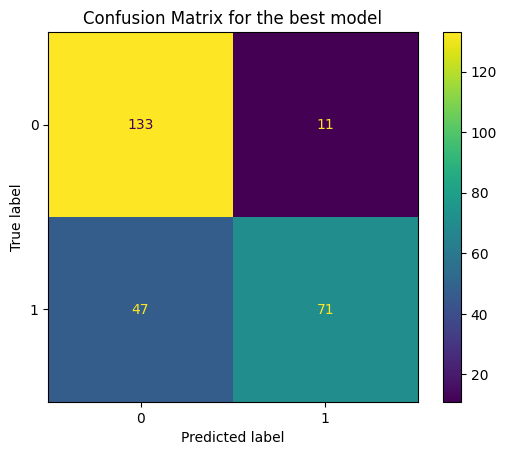

In [257]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix for the best model")
plt.show()

#### Different btwn actual and predicted values

In [261]:
pd.DataFrame({
    "Actual_Value": y_test,
    "Predicted_Value": y_test_pred,
})

,Actual_Value,Predicted_Value
1148,0,0
1049,1,0
982,0,0
808,0,0
1195,0,0
...,...,...
572,1,1
140,1,0
1182,1,1
312,0,0
